![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [ ]:
!sudo apt-get install libgomp1
!sudo apt-get install libxft2
!sudo apt-get install libglu1

[sudo] password for miranda: 
sudo: a password is required
^C
[sudo] password for miranda: 

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

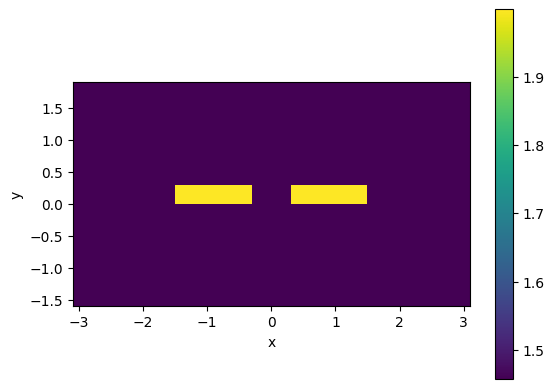

In [ ]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width. Dos términos, de las 2 guías. 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm, #separación entre las dos guías
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

12:29:45 CET WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-10 12:29:45.005 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

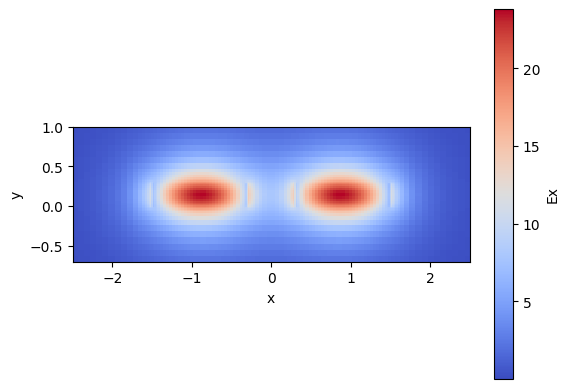

In [ ]:
#Modo 0. representamos campo X. variación horizontal. Campo positivo para ambos casos. modo par
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

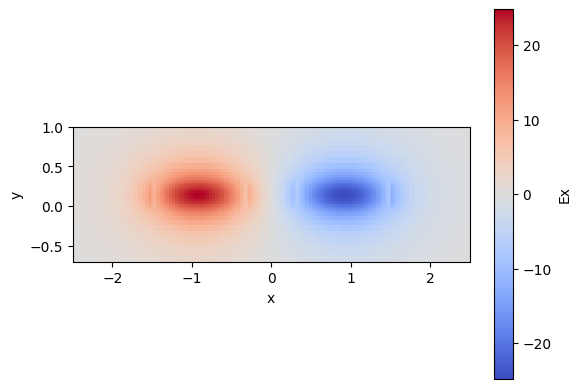

In [ ]:
#modo impar. TE tmb.
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

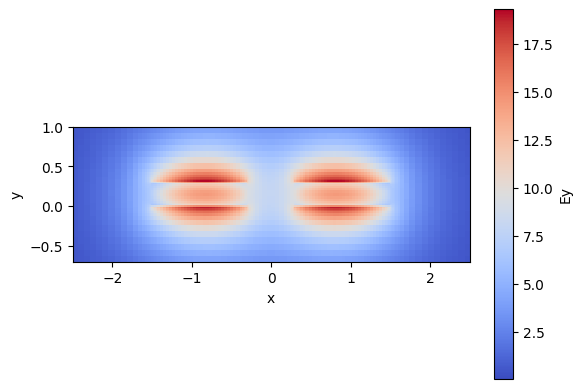

In [ ]:
#modo TM. campo Y. variación en vertical. modo par

dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

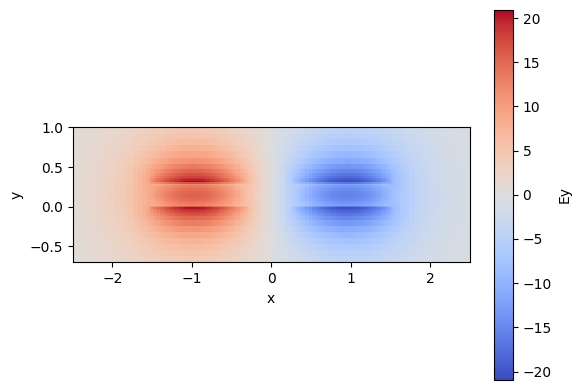

In [ ]:
#modo TM. campo Y. variación en vertical. modo impar
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [ ]:
# long de acoplo Lpi: punto dodne se acopla totalmente una guia a la otra. hay que mirar neff de los dos modos (par e impar) para modos TE y TM
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699743
52.2602236774422


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [ ]:
dcoupler_cs.coupling_length() #va bien mientras no hagamos barrido en long de onda

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

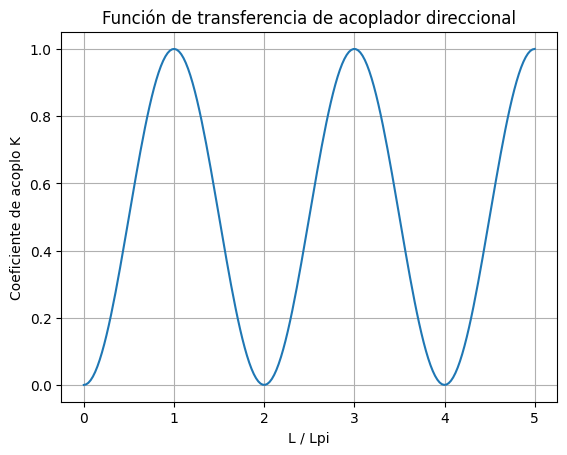

90.81065358096527
50.57441001042793
45.40532679048263
25.287205005213966


In [ ]:
#representar la funcion de k, como variable L/Lpi
# dar info de la long que se necesita en cada uno de los modos para que salga la mitad por cad modo, para que se acople una guia directamente a la otra...

#dcoupler_cs definido de antes

#MODO TE
lambda_k = 1.5

modes = dcoupler_cs.n_eff.real
neff_par = modes[0]
neff_impar = modes[1]

L_pi_TE_k = 0.5*lambda_k/(neff_par-neff_impar)

#MODO TM


neff_par_TM = modes[2]
neff_impar_TM = modes[3]

L_pi_TM_k = 0.5*lambda_k/(neff_par_TM-neff_impar_TM)



x = np.linspace(0, 5, 200)   # L/Lpi
K = np.sin(0.5 * np.pi * x)**2


plt.figure()
plt.plot(x, K)
plt.xlabel("L / Lpi")
plt.ylabel("Coeficiente de acoplo K")
plt.title("Función de transferencia de acoplador direccional")
plt.grid()
plt.show()

#para dar info de L segun lo que queremos, lo miramos en la grafica y despejamos L segun Lpi(que sera diferente en el modo TM  o TE)


# Para que Pase toda la potencia a la otra guia L=Lpi
# MODO TE
L_TE_1= L_pi_TE_k
print(L_TE_1)
# MODO TM
L_TM_1= L_pi_TM_k
print(L_TM_1)
# Para que el acoplador divida la potencia en 50/50.
# MODO TE
L_TE_2= L_pi_TE_k*0.5
print(L_TE_2)
# MODO TM
L_TM_2= L_pi_TM_k*0.5
print(L_TM_2)

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [3]:
#se simula una propagación. solo cambiar los parametros que pone #student.
#dar diferentes plots para diferentes gaps que se van poniendo. ver como cambia Lpi. cambiar wg_gap

# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605179915  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


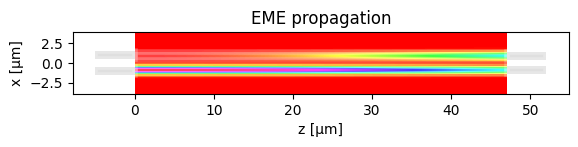

In [4]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  25.81423666493462  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/258 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.9071
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7802
Total OUT power: 0.7586
Excess loss [dB] =  1.2000
------------------------
Power over OUTs:  ['0.3792', '0.3794']
Ratio over OUTs ['0.4999', '0.5001']


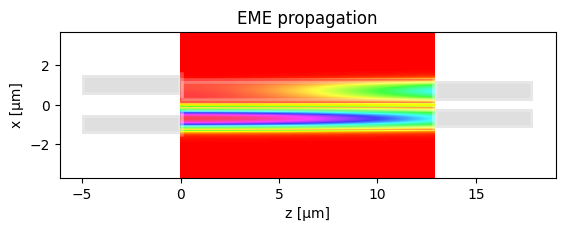

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  50.10994896216294  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/501 [00:00<?, ?it/s]

------- Pameters -------
MMI length 25.0550
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8983
Total OUT power: 0.8863
Excess loss [dB] =  0.5243
------------------------
Power over OUTs:  ['0.4433', '0.4430']
Ratio over OUTs ['0.5001', '0.4999']


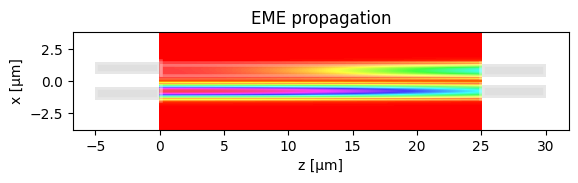

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02696947091691  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0135
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9687
Total OUT power: 0.9582
Excess loss [dB] =  0.1855
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


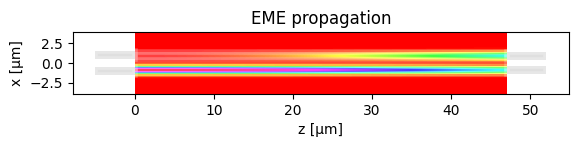

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  173.96389977147896  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']


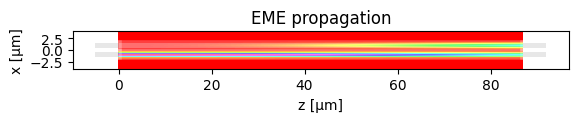

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  318.88415207663627  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']


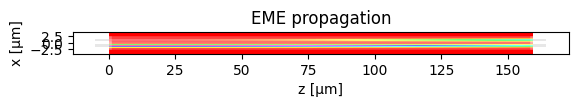

In [4]:
wg_gap = np.arange(0.2,1.2,0.2) # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate

for i in wg_gap:                    # the propagation based on the mode decomposition. 
    m.DC_wg_gap = i # Gap between waveguides
    m.DC_wg_width = wg_width # Width of the waveguides core
    m.DC_N_waveguides = wg_N

    # 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
    m.find_all_modes()

    # 2) Get the L_pi 
    L_pi = m.get_L_pi()
    print("L_pi = ", L_pi, " µm")

    m.n_IN = 2
    m.n_OUT = 2

    m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                        # some variables might be identified as "MMI". Sorry about that (: 
                        # Might change in the future 

    # 4) Run propagation - get power transfer and plot propagation
    m.propagation()
    plt.show() 

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [ ]:
# ver minima separacion para aprovechar el chip lo máximo que podamos sin que estas guias se acoplen.
#queremos ver k<0.01 una vez pasada L para que no se acoplen, para una L determinada 
#  #



Lpi necesario = 156817.09 um


In [4]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01

K= 0.01
L = 10000  # µm

L_pi = np.pi * L / (2 * np.arcsin(np.sqrt(K)))
print (f'Lpi necesario = {L_pi:.2f} um')

# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 



lambda_c = 1.55 #um

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width. Dos términos, de las 2 guías. 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=4, #um. #separación entre las dos guías
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.coupling_length()[0]



Lpi necesario = 156817.09 um
2026-04-28 20:33:56.633 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_031a6e928645d78f.npz.


np.float64(291054.8659487909)

  0%|          | 0/15 [00:00<?, ?it/s]

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

20:34:55 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-04-28 20:34:55.585 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_ca000eb2cd436bfd.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

...

2026-04-28 20:43:18.732 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_637c9c82de2f2d68.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-04-28 20:44:09.879 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e9a3b89bdca225d6.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-04-28 20:45:01.200 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8d676eb71f97c46d.npz.
2026-04-28 20:45:01.211 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_031a6e928645d78f.npz.
[ 25823.86123878  34921.65425655  46930.91266203  62443.80368434
  81817.37481705 104854.38682352 130547.60071892 157225.84241241
 183246.66598426 207682.88033567 226593.23417477 243175.49301669
 258669.65029798 274273.95395208 291054.86594879]


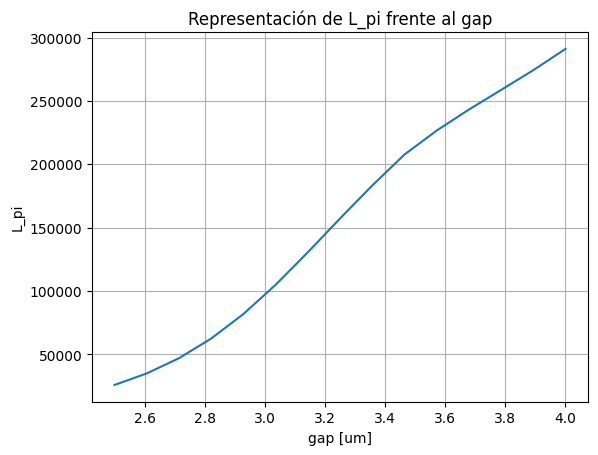

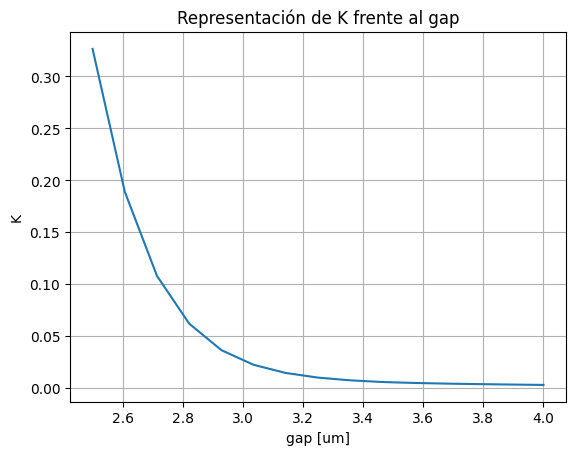

In [5]:
wg_gap = np.linspace(2.5,4,15) 
L_pi= gt.modes.sweep_coupling_length(dcoupler_cs,wg_gap)[:,0]
print(L_pi)

K= np.sin(np.pi * L / (2 * L_pi))**2

plt.figure()
plt.plot(wg_gap,L_pi )
plt.xlabel("gap [um]")
plt.ylabel("L_pi")
plt.title("Representación de L_pi frente al gap")
plt.grid()
plt.show()


plt.figure()
plt.plot(wg_gap, K)
plt.xlabel("gap [um]")
plt.ylabel("K")
plt.title("Representación de K frente al gap")
plt.grid()
plt.show()

2026-05-04 01:52:44.560 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_6ad366802df01731.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-04 01:53:52.759 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_64f3302aa271e89d.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-04 01:54:47.434 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_c31ec6128f2585eb.npz.


...

2026-05-04 02:03:05.168 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_d27b5b9a9594f605.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-04 02:04:22.873 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_94683bd800ddf4a9.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-04 02:05:43.821 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_f19e193c1794f854.npz.


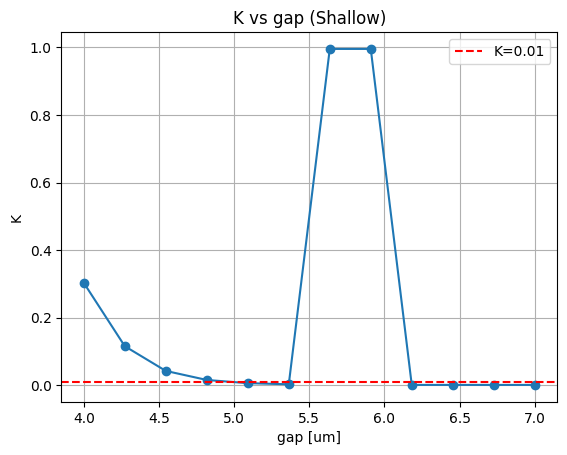

In [28]:
#SHALLOW

lambda_c = 1.55
L = 10000  # µm

gaps = np.linspace(4, 7, 12)

L_pi_list = []
K_list = []

for g in gaps:
    dcoupler_cs = gt.modes.WaveguideCoupler(
        core_width=(1, 1),
        slab_thickness=150 * nm,
        core_thickness=300 * nm,
        gap=float(g),
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    L_pi = dcoupler_cs.coupling_length()[0]
    K = np.sin(0.5 * np.pi * (L / L_pi))**2

    L_pi_list.append(L_pi)
    K_list.append(K)

# arrays
L_pi_array = np.array(L_pi_list)
K_array = np.array(K_list)

# plot
plt.figure()
plt.plot(gaps, K_array, 'o-')
plt.axhline(0.01, color='r', linestyle='--', label='K=0.01')
plt.xlabel("gap [um]")
plt.ylabel("K")
plt.title("K vs gap (Shallow)")
plt.grid()
plt.legend()
plt.show()

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [2]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section. Poner un numero muy alto para que sea mas preciso.
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

12:30:53 CET WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-24 12:30:53.907 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [3]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

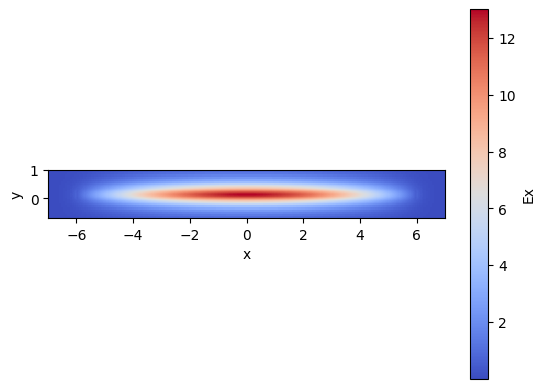

In [4]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

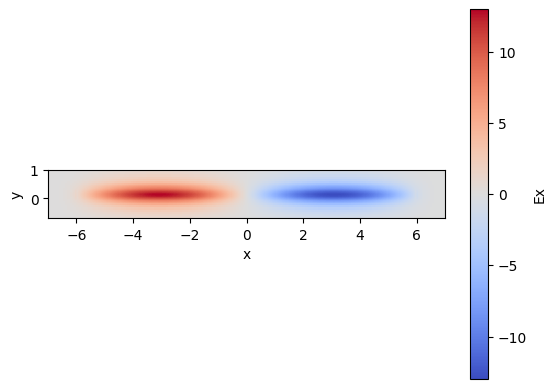

In [5]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

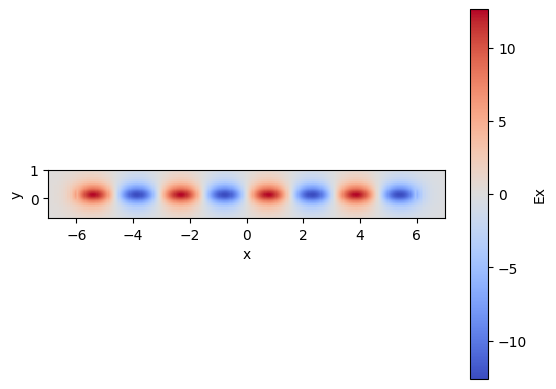

In [6]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [7]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794421252


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [3]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725696  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


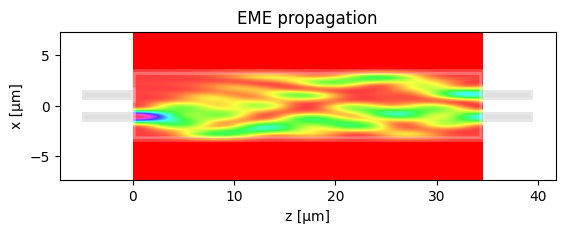

In [4]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


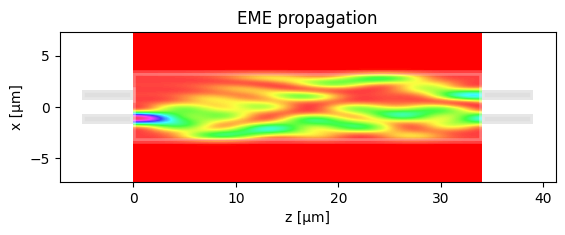

In [30]:
dy = 0.05 # STUDENT
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [46]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.8 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725655  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/699 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.4400
IO wg width 1.0000
IO wg width increment 0.8000
------------------------
Total power IN coupled 0.9956
Total OUT power: 0.9773
Excess loss [dB] =  0.0999
------------------------
Power over OUTs:  ['0.4886', '0.4886']
Ratio over OUTs ['0.5000', '0.5000']


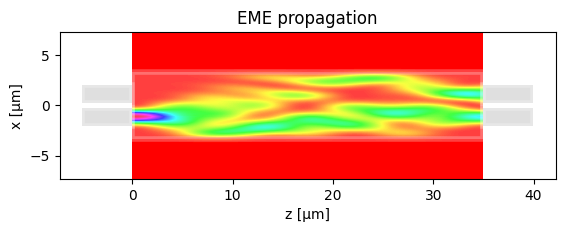

In [87]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.03
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = 0.44 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [11]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width_1x4 = 12 # Student. Body width

m_1x4 = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m_1x4.MMI_width = mmi_Width_1x4
m_1x4.wg_width_dw = 1.1
m_1x4.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m_1x4.find_all_modes()

# 2) Get the L_pi 
L_pi_1x4 = m_1x4.get_L_pi()
print("L_pi = ", L_pi_1x4, " µm")

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544112347  µm


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/802 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 1.1000
------------------------
Total power IN coupled 0.9953
Total OUT power: 0.9870
Excess loss [dB] =  0.0570
------------------------
Power over OUTs:  ['0.2400', '0.2535', '0.2535', '0.2399']
Ratio over OUTs ['0.2432', '0.2569', '0.2569', '0.2431']


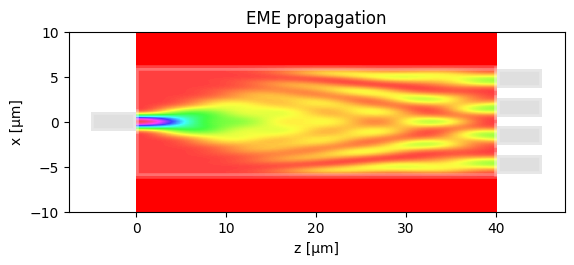

In [18]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m_1x4.n_IN =  1 # STUDENT
m_1x4.n_OUT = 4 # STUDENT

# Ajuste fino
dy = 0.1  

# MMI I/O waveguide positions (check class slides for type of MMI)
m_1x4.IN_WVG_positions = np.array([0])# STUDENT
m_1x4.OUT_WVG_positions = m_1x4.MMI_width * np.array([-3/6, -1/6, 1/6, 3/6]) + np.array([1.25, 0.45, -0.45, -1.25]) # STUDENT

# MMI length (check class slides for type of MMI)
m_1x4.L_MMI = (3/16)*L_pi_1x4 # STUDENT

m_1x4.dL_MMI = -1# STUDENT

# Run propagation
m_1x4.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

17:44:59 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-05-03 17:44:59.811 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-03 17:45:33.373 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_266d67620f0948f9.npz.


...

2026-05-03 17:52:00.619 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8e0bd02e52bb6fea.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-03 17:52:40.992 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cbd4017b74156e86.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-03 17:53:37.023 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_186b33d829047bed.npz.


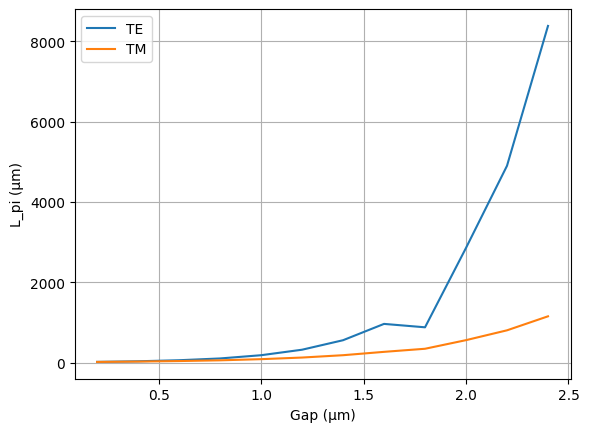

In [9]:
gap_to_simulate =  np.arange(0.2, 2.6, 0.2) # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

wavelength = 1.55

L_pi_TE = []
L_pi_TM = []

for g in gap_to_simulate:

    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=float(g),
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

# STUDENT. Plot goes here
    neff = deep_dcoupler_cs.n_eff

    L_pi_TE.append(0.5 * wavelength / (neff[0].real - neff[1].real))
    L_pi_TM.append(0.5 * wavelength / (neff[2].real - neff[3].real))

# PLOT
plt.plot(gap_to_simulate, L_pi_TE, label="TE")
plt.plot(gap_to_simulate, L_pi_TM, label="TM")
plt.xlabel("Gap (µm)")
plt.ylabel("L_pi (µm)")
plt.legend()
plt.grid()
plt.show()   


2026-05-03 23:31:17.377 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b7e41e390984216d.npz.
[0.99637097 0.99504631 0.00641708 0.98572277 0.99949031]
2026-05-03 23:31:17.402 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d756dff4f5b09319.npz.
[0.9960711  0.99582653 0.00722566 0.96935971 0.99761581]
2026-05-03 23:31:17.413 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1c97aadcfff61591.npz.
[0.99608423 0.99590382 0.00926979 0.93662072 0.99388697]
2026-05-03 23:31:17.426 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cb0d5d890abbd68b.npz.
[0.99600136 0.99575108 0.01218669 0.89045055 0.98812077]
2026-05-03 23:31:17.434 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9e9855bfd484b4ef.npz.
[0.9961233  0.99592524 0.0159683  0.78907736 0.2489601 ]
2026-05-03 23:31:17.445 | INFO     | gplugins.tidy3d.mo

[0.9958434  0.99572437 0.04452309 0.5439485  0.30087384]
2026-05-03 23:31:17.483 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_bfc5001039f26e5f.npz.
[0.99608892 0.99600486 0.04913282 0.44457332 0.40506504]
2026-05-03 23:31:17.494 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_60ad39471eda45f0.npz.
[0.99607992 0.99601514 0.0578694  0.42988408 0.42943462]
2026-05-03 23:31:17.507 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1adb96126bff44d4.npz.
[0.99607419 0.99602478 0.42512384 0.06705656 0.44385506]


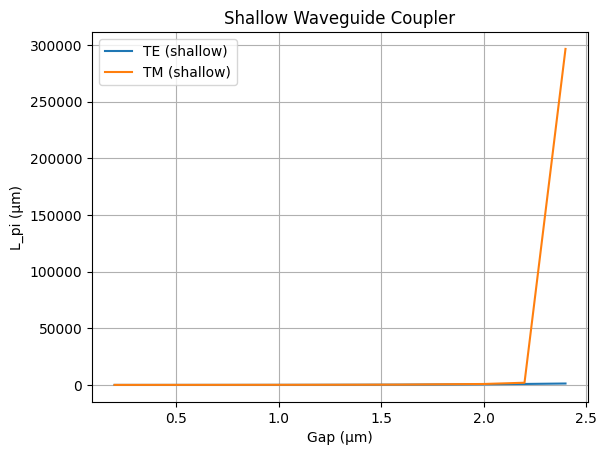

In [19]:
#GUÍA SHALLOW

gap_to_simulate = np.arange(0.2, 2.6, 0.2)

wavelength = 1.55

L_pi_TE = []
L_pi_TM = []

for g in gap_to_simulate:

    shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=float(g),
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=5, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    neff = shallow_dcoupler_cs.n_eff

    # TE (siguen siendo los dos primeros normalmente)
    L_pi_TE.append(0.5 * wavelength / (neff[0].real - neff[1].real))

    # ⚠ TM puede cambiar → usamos 2 y 3 (lo más común)
    L_pi_TM.append(0.5 * wavelength / (neff[2].real - neff[3].real))

    print(shallow_dcoupler_cs.fraction_te)

# PLOT
plt.plot(gap_to_simulate, L_pi_TE, label="TE (shallow)")
plt.plot(gap_to_simulate, L_pi_TM, label="TM (shallow)")
plt.xlabel("Gap (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Shallow Waveguide Coupler")
plt.legend()
plt.grid()
plt.show()

### E2. Directional coupler wavelength dependence

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-03 23:57:55.858 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_768317721804666d.npz.


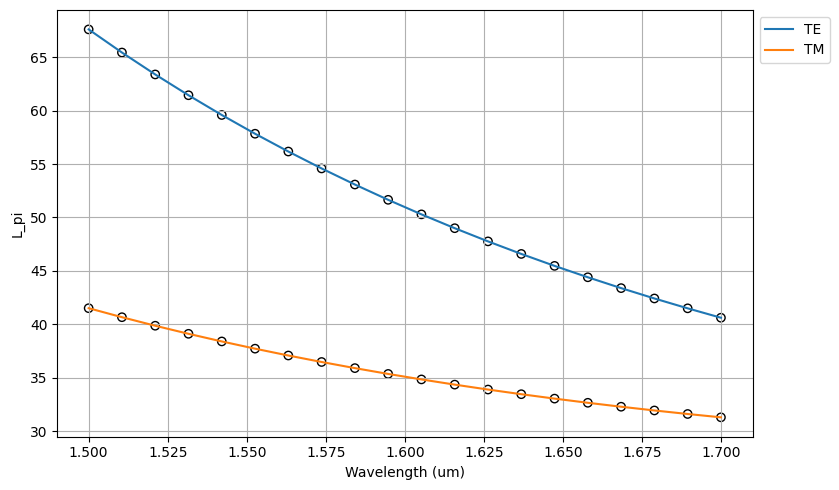

In [20]:
wavelength = np.linspace(1.5, 1.7, 20) # STUDENT code goes here



deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

    
deep_neff = deep_dcoupler_cs.n_eff
# TE
L_pi_TE =  0.5 * wavelength / (deep_neff[:,0].real - deep_neff[:,1].real) # STUDENT code here

# TM
L_pi_TM= 0.5 * wavelength / (deep_neff[:,2].real - deep_neff[:,3].real) # STUDENT code here



plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none')
plt.plot(wavelength, L_pi_TE,label='TE')

plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none')
plt.plot(wavelength, L_pi_TM, label='TM')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

00:23:16 CEST WARNING: Mode field at frequency index 0, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 1, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 2, mode index 2 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 3, mode index 2 does not   
              decay at the plane boundaries.                                    

...

              WARNING: Mode field at frequency index 16, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 17, mode index 2 does not  
              decay at the plane boundaries.                                    

00:23:17 CEST WARNING: Mode field at frequency index 18, mode index 2 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 19, mode index 2 does not  
              decay at the plane boundaries.                                    

2026-05-04 00:23:17.152 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_788e94ff4f3e4458.npz.


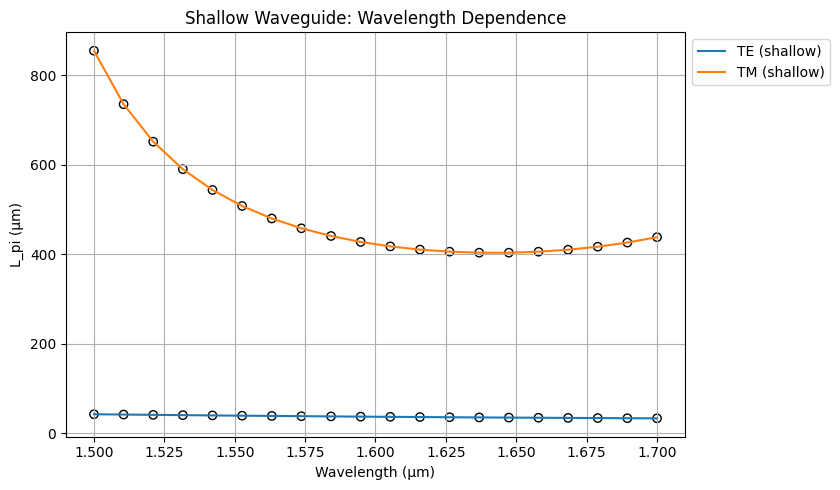

In [21]:
#SHALLOW

wavelength = np.linspace(1.5, 1.7, 20)




shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid

)

neff = shallow_dcoupler_cs.n_eff

# TE
L_pi_TE =  0.5 * wavelength / (neff[:,0].real - neff[:,1].real) # STUDENT code here

# TM
L_pi_TM= 0.5 * wavelength / (neff[:,2].real - neff[:,3].real) # STUDENT code here



# PLOT
plt.figure(figsize=(10, 5))

plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none')
plt.plot(wavelength, L_pi_TE, label='TE (shallow)')
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none')
plt.plot(wavelength, L_pi_TM, label='TM (shallow)')

plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Shallow Waveguide: Wavelength Dependence")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

### E3. MMI coupler wavelength dependence

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

22:15:37 CEST WARNING: Mode '12' appears to undergo a discontinuous change      
              between frequencies '191786420942760.94' and '190503568628762.53' 
              (overlap: '0.83').                                                

              WARNING: Mode '14' appears to undergo a discontinuous change      
              between frequencies '191786420942760.94' and '190503568628762.53' 
              (overlap: '0.83').                                                

              WARNING: Mode '7' appears to undergo a discontinuous change       
              between frequencies '195740780137457.03' and '194404665597269.62' 
              (overlap: '0.81').                                                

              WARNING: Mode '8' appears to undergo a discontinuous change       
              between frequencies '195740780137457.03' and '194404665597269.62' 
              (overlap: '0.81').                                                

...

              WARNING: Mode field at frequency index 18, mode index 14 does not 
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 19, mode index 12 does not 
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 19, mode index 13 does not 
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 19, mode index 14 does not 
              decay at the plane boundaries.                                    

2026-05-03 22:15:42.674 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_91714e274270fef4.npz.


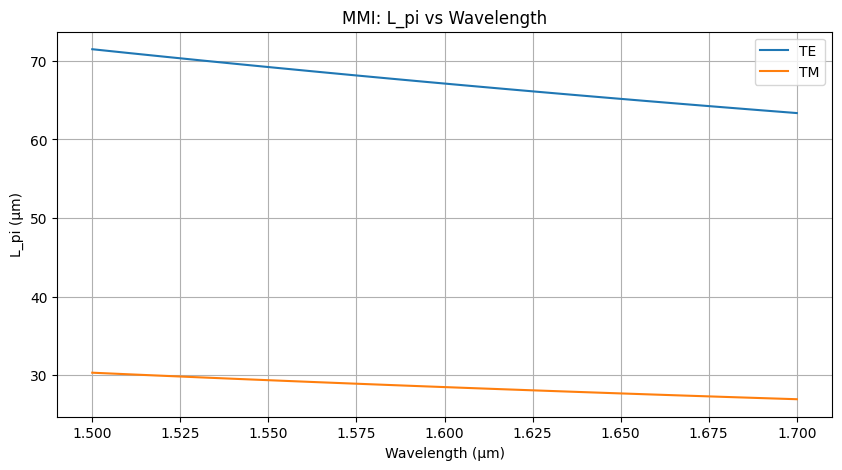

In [7]:
mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.7, 20) # STUDENT code goes here.


mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

neff = mmi_body_waveguide.n_eff

#TE
d_n_eff_TE = neff[:,0].real - neff[:,1].real
L_pi_TE = 0.5 * lambda_c / d_n_eff_TE

#TM
d_n_eff_TM = neff[:,2].real - neff[:,3].real
L_pi_TM = 0.5 * lambda_c / d_n_eff_TM
    

# STUDENT plot here. 
plt.figure(figsize=(10, 5))

plt.plot(lambda_c, L_pi_TE, label='TE')
plt.plot(lambda_c, L_pi_TM, label='TM')

plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("MMI: L_pi vs Wavelength")
plt.grid()
plt.legend()
plt.show()

2026-05-03 22:51:26.084 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a179ff10a06db935.npz.


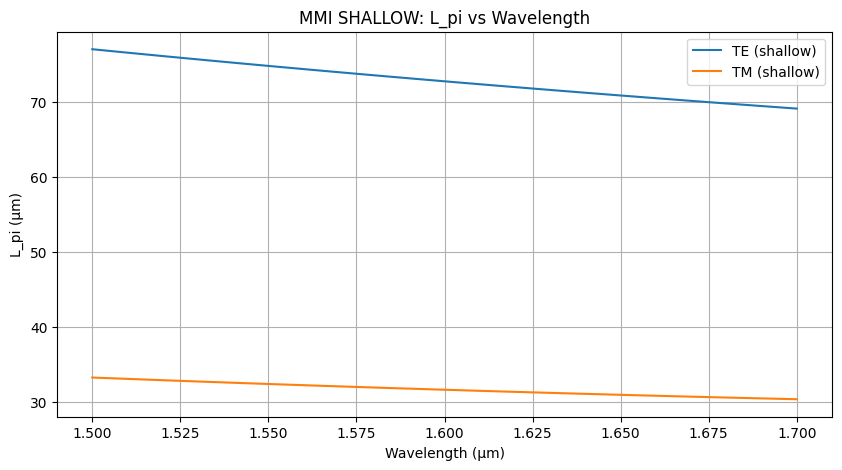

In [10]:
#SHALLOW

mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.7, 20) # STUDENT code goes here.


mmi_body_wg_shallow = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

neff =  mmi_body_wg_shallow.n_eff

#TE
d_n_eff_TE = neff[:,0].real - neff[:,1].real
L_pi_TE = 0.5 * lambda_c / d_n_eff_TE

#TM
d_n_eff_TM = neff[:,2].real - neff[:,3].real
L_pi_TM = 0.5 * lambda_c / d_n_eff_TM


#PLOT
plt.figure(figsize=(10, 5))

plt.plot(lambda_c, L_pi_TE, label='TE (shallow)')
plt.plot(lambda_c, L_pi_TM, label='TM (shallow)')

plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("MMI SHALLOW: L_pi vs Wavelength")
plt.grid()
plt.legend()
plt.show()

### E4. MMI coupler body width dependence

/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

20:42:22 CEST WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 10 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

20:42:23 CEST WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

...

2026-05-03 21:05:46.217 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ef086336c0da3b23.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-03 21:07:17.163 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_badabc375bd90f8b.npz.


/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/miranda/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-03 21:08:53.033 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0715b5214f4328e7.npz.


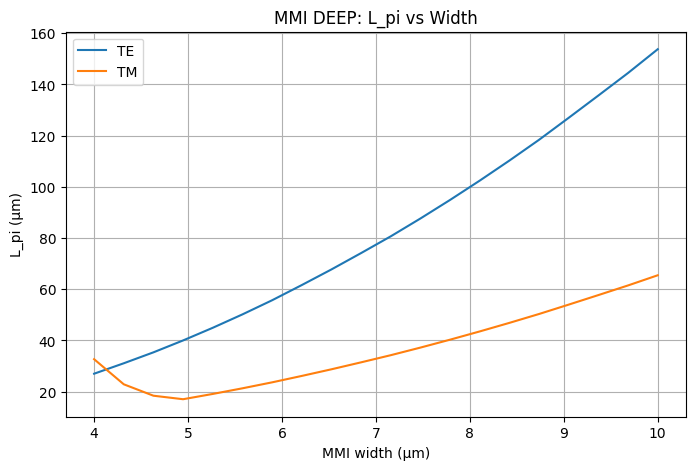

In [4]:
lambda_c = 1.55

mmi_body_w =  np.linspace(4, 10, 20)# STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

L_pi_TE = []
L_pi_TM = []

for w in mmi_body_w :

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    neff=mmi_body_waveguide.n_eff

    #TE
    d_n_eff_TE = neff[0].real -  neff[1].real
    L_pi_TE.append(0.5 * lambda_c / d_n_eff_TE)

    #TM
    d_n_eff_TM = neff[2].real - neff[3].real
    L_pi_TM.append(0.5 * lambda_c / d_n_eff_TM)

# STUDENT plot here. 

plt.figure(figsize=(8,5))

plt.plot(mmi_body_w , L_pi_TE, label="TE")
plt.plot(mmi_body_w , L_pi_TM, label="TM")

plt.xlabel("MMI width (µm)")
plt.ylabel("L_pi (µm)")
plt.title("MMI DEEP: L_pi vs Width")
plt.grid()
plt.legend()
plt.show()

2026-05-03 21:40:02.306 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fd186c8201308491.npz.
2026-05-03 21:40:02.355 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bd512d1f0fe0dbb6.npz.
2026-05-03 21:40:02.358 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5c7907fa45b75d2f.npz.
2026-05-03 21:40:02.361 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4afcca93ac5eca58.npz.
2026-05-03 21:40:02.366 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4e42f8955b23b234.npz.
2026-05-03 21:40:02.371 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1af84e3cf75b2203.npz.
2026-05-03 21:40:02.375 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1bbaece35b0563f5.npz.
2026-05-03 21:40:02.380 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_069554ac38cfa8fd.npz.


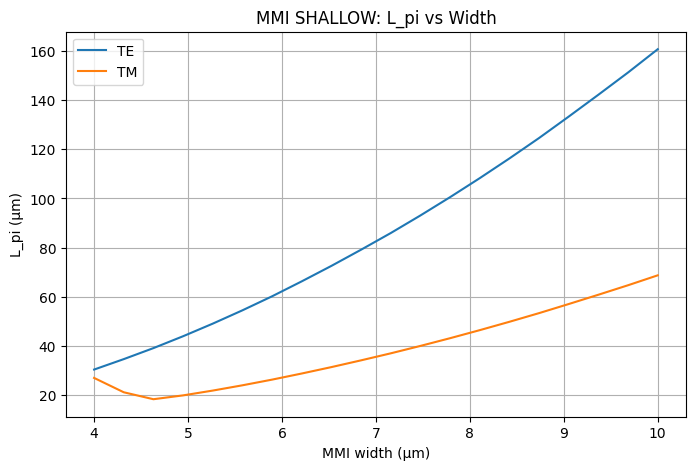

In [6]:
#SHALLOW
lambda_c = 1.55

mmi_body_w =  np.linspace(4, 10, 20)# STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

L_pi_TE = []
L_pi_TM = []

for w in mmi_body_w :

    mmi_body_wg_shallow = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    neff=mmi_body_wg_shallow.n_eff

    #TE
    d_n_eff_TE = neff[0].real -  neff[1].real
    L_pi_TE.append(0.5 * lambda_c / d_n_eff_TE)

    #TM
    d_n_eff_TM = neff[2].real - neff[3].real
    L_pi_TM.append(0.5 * lambda_c / d_n_eff_TM)

# STUDENT plot here. 

plt.figure(figsize=(8,5))

plt.plot(mmi_body_w , L_pi_TE, label="TE")
plt.plot(mmi_body_w , L_pi_TM, label="TM")

plt.xlabel("MMI width (µm)")
plt.ylabel("L_pi (µm)")
plt.title("MMI SHALLOW: L_pi vs Width")
plt.grid()
plt.legend()
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points